In [14]:
## set project root
import sys, os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, project_root)

assets_dir = os.path.join(project_root, "assets")

# Import Packages

We'll make use of the following packages:
- `numpy` is a package for scientific computing in python.
- `pandas` A powerful Python library for data manipulation and analysis.
- `seaborn` A data visualization library based on matplotlib.
- `scikit-learn` A comprehensive library for machine learning in Python.
- `kaggle` Using Kaggle API to download data.

In [248]:
import pandas as pd
import numpy as np
import seaborn as sns
import kagglehub
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import logging
import importlib
import src.data_preprocessing
import src.eda
importlib.reload(src.data_preprocessing)
importlib.reload(src.eda)
from src.data_preprocessing import DataPreprocessor
from src.eda import NumericalEDA, CategoricalEDA
from typing import List, Optional, Union
from scipy.stats import loguniform, uniform
from itertools import chain
import warnings
from io import StringIO

from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error



# Download Data

In [17]:
# Download latest version
path = kagglehub.dataset_download("taeefnajib/used-car-price-prediction-dataset")

print(os.listdir(path))

['used_cars.csv']


## Check data

In [19]:
## Check data
df = pd.read_csv(os.path.join(path, "used_cars.csv"))

# Data Preprocessing via pipeline

In [ ]:
# Data Preprocessing via pipeline
dp = DataPreprocessor(df,assets_dir=assets_dir)
df_new = dp.preprocess()

COMPLETE: rename_column. -
 {'milage': 'mileage'}
No missing values found.
Data preprocessing completed successfully.


# EDA

In [21]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                4009 non-null   object 
 1   model                4009 non-null   object 
 2   model_year           4009 non-null   int64  
 3   mileage              4009 non-null   float64
 4   fuel_type            4009 non-null   object 
 5   engine               4009 non-null   object 
 6   transmission         4009 non-null   object 
 7   ext_col              4009 non-null   object 
 8   int_col              4009 non-null   object 
 9   accident             4009 non-null   object 
 10  clean_title          4009 non-null   int64  
 11  price                4009 non-null   float64
 12  transmission_type    4009 non-null   object 
 13  transmission_speeds  4009 non-null   float64
 14  hp                   4009 non-null   float64
 15  liters               4009 non-null   f

Column names and new features are showing as expected.

In [105]:
df_ml = df_new[['brand', 'model', 'model_year', 'mileage', 'fuel_type',
                'clean_title','transmission_type', 'transmission_speeds', 
                'hp', 'liters','cylinders', 'ext_color_std', 'int_col_std', 
                'accident_reported', 'price']]
df_ml.head()

,brand,model,model_year,mileage,fuel_type,clean_title,transmission_type,transmission_speeds,hp,liters,cylinders,ext_color_std,int_col_std,accident_reported,price
0,Ford,Utility Police Interceptor Base,2013,51000.0,E85 Flex Fuel,1,Automatic,6.0,300.0,3.7,6.0,black,black,1,10300.0
1,Hyundai,Palisade SEL,2021,34742.0,Gasoline,1,Automatic,8.0,291.0,3.8,6.0,blue,gray,1,38005.0
2,Lexus,RX 350,2022,22372.0,Gasoline,0,Automatic,8.0,295.0,3.5,6.0,blue,black,0,54598.0
3,INFINITI,Q50 Hybrid Sport,2015,88900.0,Hybrid,1,Automatic,7.0,354.0,3.5,6.0,black,black,0,15500.0
4,Audi,Q3 45 S line Premium Plus,2021,9835.0,Gasoline,0,Automatic,8.0,228.0,2.0,4.0,white,black,0,34999.0


## Log transforms on `mileage`, `hp`, and `price`

In EDA, strong right-skew in `mileage`, `hp`, and especially `price`. Applying a log transform reduces skew, stabilizes variance, and makes multiplicative effects closer to linear.

**Result below as expected**:
- The histograms of **_log* are much more symmetric; whiskers shrink and extreme outliers are dampened.
- `price_log` looks near-normal; `hp_log` is close; `mileage_log` is improved but still a bit right-skewed.

💡 Linear models assume linear relationships and roughly homoscedastic residuals. Logs often linearize price vs. features and reduce heteroscedasticity, which can improve fit and inference.


In [106]:
cat_cols = ['brand', 'model', 'fuel_type', 'clean_title','transmission_type','ext_color_std', 'int_col_std', 'accident_reported']
log_tf_cols = ["mileage", "hp", "price"]
log_cols = [c + '_log' for c in log_tf_cols]

## take logs for right tailed features
df_ml = df_ml.copy()
df_ml[log_cols] = np.log1p(df_ml[log_tf_cols])

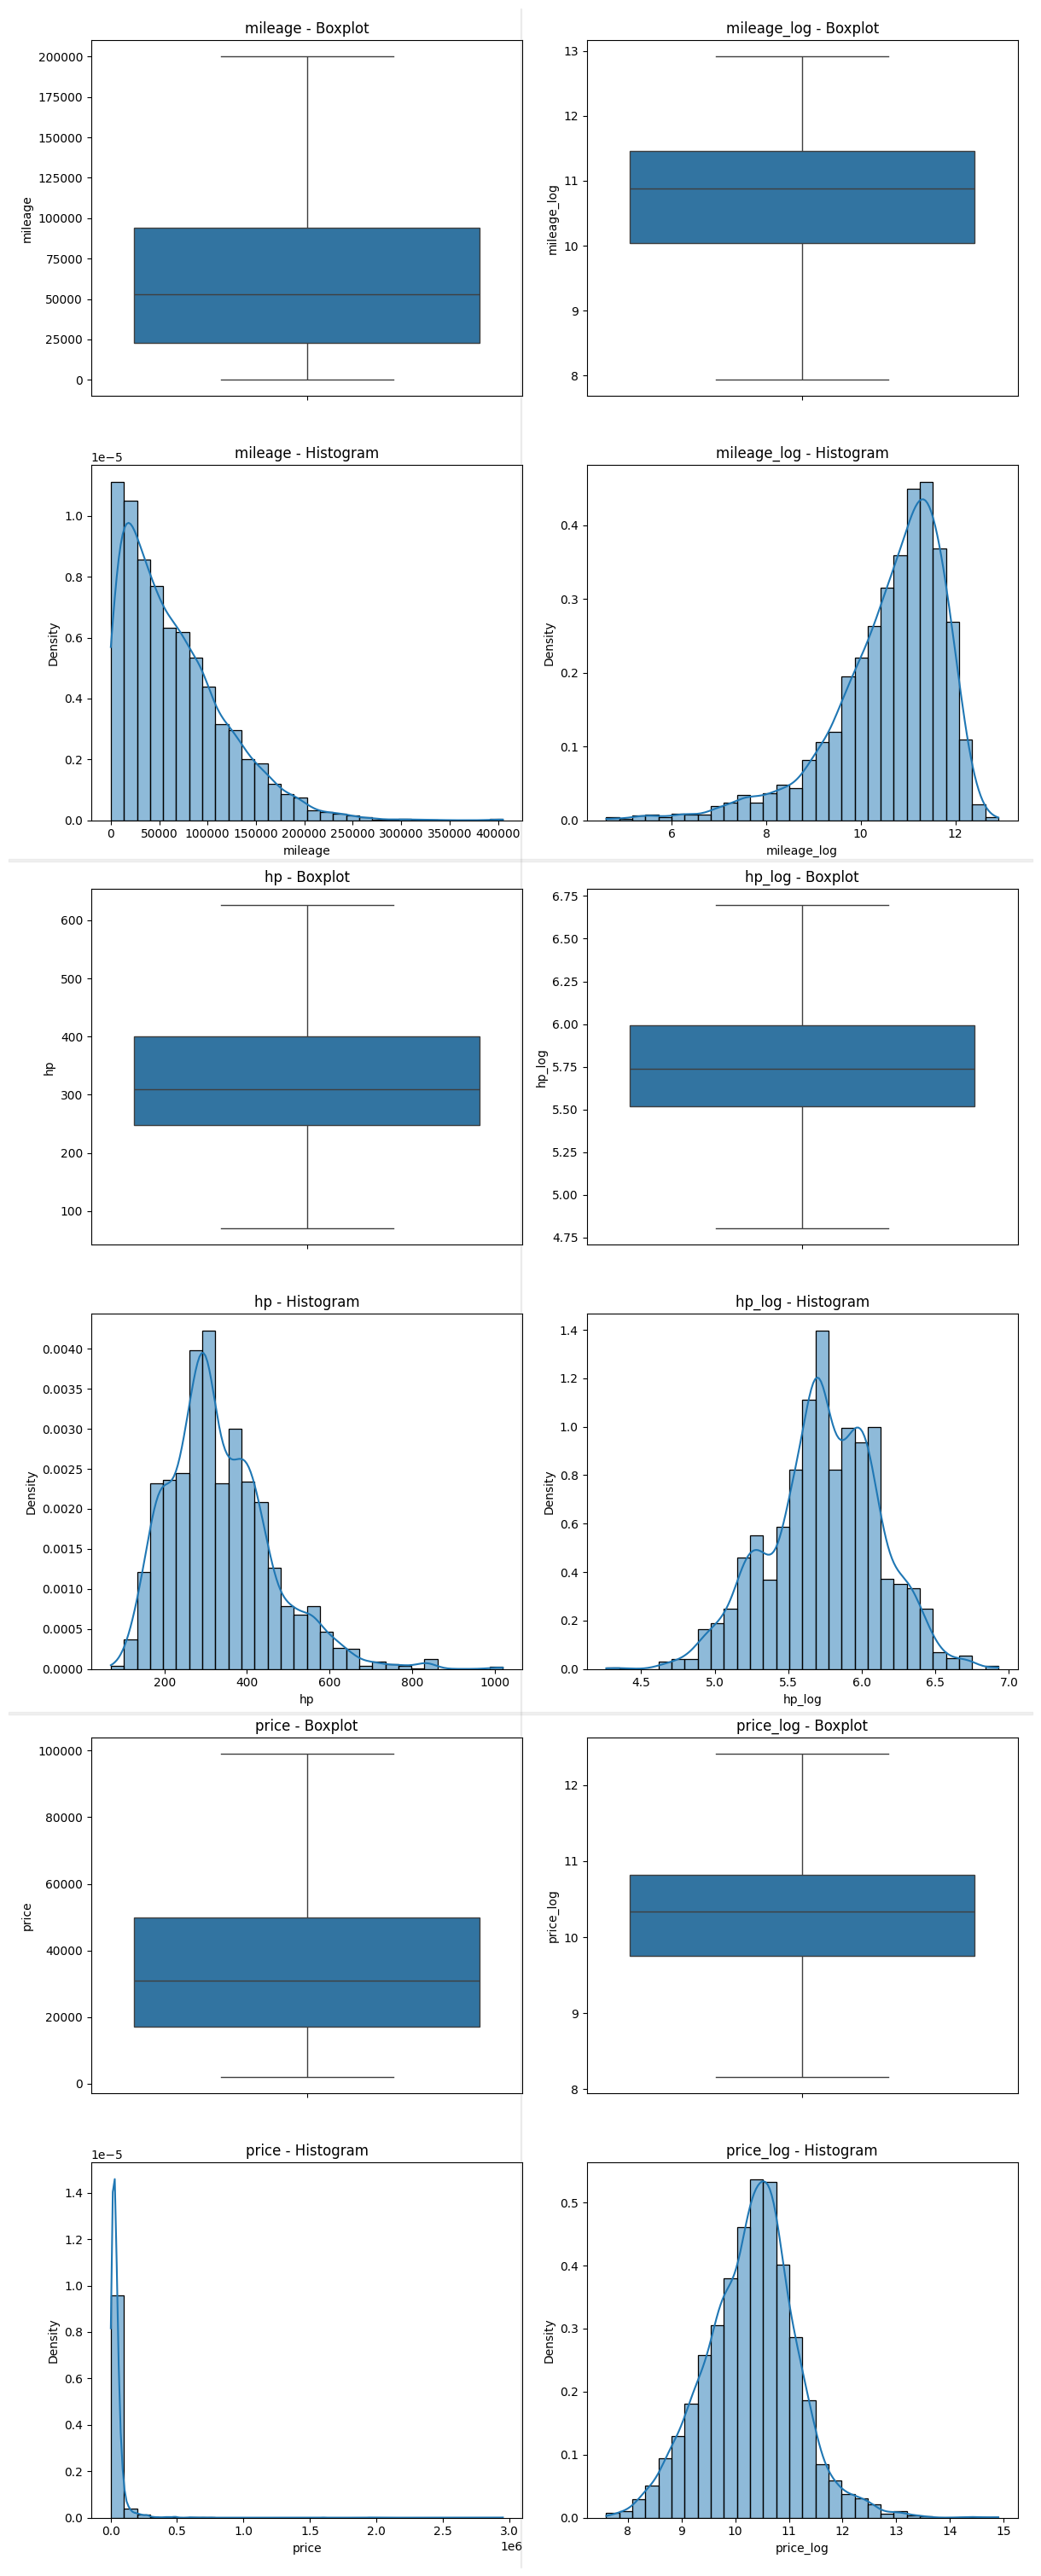

In [108]:
compare_cols=list(chain.from_iterable(list(zip(log_tf_cols, log_cols))))

num_eda = NumericalEDA(df_ml, cat_cols=cat_cols, target_col="price")
num_eda.plot_box_and_hist_per_feature(compare_cols=compare_cols)

## Pipeline

### Linear Regression: Regular

In [291]:
def make_preprocessor(X):
    col_cat = X.select_dtypes(include="object").columns.tolist()
    col_num = X.select_dtypes(include="number").columns.tolist()
    ohe = OneHotEncoder(
        handle_unknown="infrequent_if_exist", 
        min_frequency=2, 
        sparse_output=True, 
        drop="if_binary"
    )
    return ColumnTransformer(
        [('num', StandardScaler(), col_num),
         ('cat', ohe, col_cat)],
        sparse_threshold=1.0
    )

def lasso_alpha_max(preprocessor, X, y):
    """Calculate maximum alpha for Lasso regularization path."""
    pre_fit = preprocessor.fit(X)
    Xt = pre_fit.transform(X)
    
    # Convert to dense if sparse for dot product calculation
    if hasattr(Xt, 'toarray'):
        Xt = Xt.toarray()
    
    # Standard Lasso alpha_max calculation
    y_centered = y - y.mean()
    alpha_max = 2 * np.abs(Xt.T.dot(y_centered)).max() / X.shape[0]
    
    if alpha_max == 0 or not np.isfinite(alpha_max):
        alpha_max = 1.0
    
    return alpha_max

def Linear_Regression(X_train, X_test, y_train, y_test, log_flag=False, reverse_log = False):
    preprocessor = make_preprocessor(X=X_train)
    alpha_max = lasso_alpha_max(preprocessor, X_train, y_train)


    ## models and parameters
    models_and_params = {
        "LinearRegression": (
            LinearRegression(),
            {}
        ),
        "Ridge": (
            Ridge(random_state=42),
            {"model__alpha": loguniform(1e-4, 1e3)}
        ),
        "Lasso": (
            Lasso(max_iter=200_000, tol=1e-4, selection="random", random_state=42),
            {"model__alpha": loguniform(alpha_max*1e-4, alpha_max)}
        ),
        "ElasticNet": (
            ElasticNet(max_iter=200_000, random_state=42),
            {
                "model__alpha": loguniform(alpha_max*1e-4, alpha_max),
                "model__l1_ratio": uniform(0.1, 0.9)
            }
        ),
    }

    ## Store best models
    best_models = {}
    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    # Capture stderr to suppress warnings
    old_stderr = sys.stderr
    sys.stderr = captured_output = StringIO()

    ## Grid Search
    for model_name, (model, param) in models_and_params.items():
        print(f'\n--- Tuning {model_name} ---')
        print(f"Training Dimenstion:", X_train.shape)
        pipeline = Pipeline([
            ("pre", preprocessor),
            ("model", model)
        ])

        if model_name == "LinearRegression":
            pipeline.fit(X_train, y_train)
            best_model = pipeline
            print(f'{model_name}: No hyperparameters to tune')
        else:
            search = RandomizedSearchCV(estimator=pipeline, 
                                        param_distributions = param, 
                                        n_iter=40,
                                        scoring="neg_root_mean_squared_error", 
                                        cv=cv, 
                                        n_jobs=min(10, os.cpu_count()-1), 
                                        pre_dispatch="2*n_jobs",
                                        random_state=42,
                                        verbose=1
                                        )

            search.fit(X_train, y_train)
            
            print(f'Best params for {model_name}: {search.best_params_}')
            print(f'Best CV RMSE for {model_name}: {search.best_score_}')

            best_model = search.best_estimator_
        
        best_models[model_name] = best_model
    
    ## Model Diagnostics
    def adjusted_r2(r2, n, k):
        return 1 - (1-r2) * ((n-1) / (n-k-1))

    for name, model in best_models.items():
        y_pred = model.predict(X_test)

        ## Transform y back to original scale
        if reverse_log:
            y_pred_log_clipped = np.clip(y_pred, -700, 700)  # Prevent overflow
            y_test_log_clipped = np.clip(y_test, -700, 700)
            y_pred = np.expm1(y_pred_log_clipped)
            y_test_original = np.expm1(y_test_log_clipped)  # Keep original name
        else:
            y_test_original = y_test

        rmse = root_mean_squared_error(y_true=y_test_original, y_pred=y_pred)
        r2 = r2_score(y_true=y_test_original, y_pred=y_pred)
        print(f'\n{name} Test RMSE: {rmse:,.2f}, R^2: {r2:.4f}')

        plt.figure(figsize=(8,6))
        sns.scatterplot(x=y_test_original, y=y_pred, alpha=0.7)
        plt.plot([y_test_original.min(), y_test_original.max()], 
                [y_test_original.min(), y_test_original.max()], 
                'r--', label='Perfect Prediction')
        if log_flag:
            plt.xlabel('Actual Price (Logged))')
            plt.ylabel('Predicted Price (Logged)')
        else:
            plt.xlabel('Actual Price ($)')
            plt.ylabel('Predicted Price ($)')
        plt.title(f'{name} - Actual vs Predicted')
        plt.legend()
        plt.show()
    return best_models

### Linear Regression: Bias Correction After Log Transformation of Price

In [303]:
# y_train and y_test are ALREADY log(price)
# DO NOT use TransformedTargetRegressor or LogTransformer in the pipeline!
def calculate_bias_correction(model, X_train, y_train_log):
    """Calculate bias correction factor using training set residuals."""
    y_pred_train_log = model.predict(X_train)
    residuals_train = y_train_log - y_pred_train_log
    correction_factor = np.mean(np.exp(residuals_train))
    return correction_factor

def Linear_Regression_Log(X_train, X_test, y_train_log, y_test_log):
    preprocessor = make_preprocessor(X=X_train)
    alpha_max = lasso_alpha_max(preprocessor, X_train, y_train_log)
    
    models_and_params = {
        "LinearRegression": (
            LinearRegression(),
            {}
        ),
        "Ridge": (
            Ridge(random_state=42),
            {"model__alpha": loguniform(1e-4, 1e3)}
        ),
        "Lasso": (
            Lasso(max_iter=200_000, tol=1e-4, selection="random", random_state=42),
            {"model__alpha": loguniform(alpha_max*1e-4, alpha_max)}
        ),
        "ElasticNet": (
            ElasticNet(max_iter=200_000, random_state=42),
            {
                "model__alpha": loguniform(alpha_max*1e-4, alpha_max),
                "model__l1_ratio": uniform(0.1, 0.9)
            }
        ),
    }

    best_models = {}
    bias_corrections = {}
    cv = KFold(n_splits=10, shuffle=True, random_state=42)

    for model_name, (model, param) in models_and_params.items():
        print(f'\n--- Tuning {model_name} ---')
        pipeline = Pipeline([
            ("pre", preprocessor),
            ("model", model)
        ])
        
        if model_name == "LinearRegression":
            pipeline.fit(X_train, y_train_log)
            best_model = pipeline
            print(f'{model_name}: No hyperparameters to tune')
        else:
            search = RandomizedSearchCV(estimator=pipeline, 
                                        param_distributions = param, 
                                        n_iter=40,
                                        scoring="neg_root_mean_squared_error", 
                                        cv=cv, 
                                        n_jobs=min(10, os.cpu_count()-1), 
                                        pre_dispatch="2*n_jobs",
                                        random_state=42,
                                        verbose=1
                                        )
        
            search.fit(X_train, y_train_log)
            print(f'Best params for {model_name}: {search.best_params_}')
            print(f'Best CV RMSE for {model_name}: {-search.best_score_:.4f}')
            
            best_model = search.best_estimator_
        best_models[model_name] = best_model
        
        # Calculate bias correction using TRAINING set residuals
        bias_corrections[model_name] = calculate_bias_correction(
            best_model, X_train, y_train_log
        )
        print(f'Bias correction factor for {model_name}: {bias_corrections[model_name]:.4f}')

    # Model Diagnostics
    print(f"\n{'='*50}")
    print("TEST SET EVALUATION")
    print(f"{'='*50}")
    
    for name, model in best_models.items():
        y_pred_log = model.predict(X_test)
        
        # Apply bias correction calculated from training set
        correction_factor = bias_corrections[name]
        y_pred_corrected = np.expm1(y_pred_log) * correction_factor
        
        # Also calculate uncorrected predictions for comparison
        y_pred_uncorrected = np.expm1(y_pred_log)
        y_true = np.expm1(y_test_log)
        
        # Calculate metrics for both corrected and uncorrected
        rmse_corrected = np.sqrt(np.mean((y_true - y_pred_corrected) ** 2))
        mae_corrected = np.mean(np.abs(y_true - y_pred_corrected))
        mape_corrected = np.mean(np.abs((y_true - y_pred_corrected) / y_true)) * 100
        
        rmse_uncorrected = np.sqrt(np.mean((y_true - y_pred_uncorrected) ** 2))
        mae_uncorrected = np.mean(np.abs(y_true - y_pred_uncorrected))
        mape_uncorrected = np.mean(np.abs((y_true - y_pred_uncorrected) / y_true)) * 100
        
        print(f'\n{name} Test Metrics:')
        print(f'  Uncorrected - RMSE: ${rmse_uncorrected:,.2f}, MAE: ${mae_uncorrected:,.2f}, MAPE: {mape_uncorrected:.2f}%')
        print(f'  Corrected   - RMSE: ${rmse_corrected:,.2f}, MAE: ${mae_corrected:,.2f}, MAPE: {mape_corrected:.2f}%')
        print(f'  Improvement - RMSE: ${rmse_uncorrected - rmse_corrected:+,.2f} ({((rmse_uncorrected - rmse_corrected)/rmse_uncorrected*100):+.1f}%)')
        
        # Create comparison scatter plot
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        # Uncorrected predictions
        ax1.scatter(y_true, y_pred_uncorrected, alpha=0.6)
        min_val, max_val = y_true.min(), y_true.max()
        ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        ax1.set_xlabel('Actual Price ($)')
        ax1.set_ylabel('Predicted Price ($)')
        ax1.set_title(f'{name} - Uncorrected\nRMSE: ${rmse_uncorrected:,.0f}')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # Corrected predictions
        ax2.scatter(y_true, y_pred_corrected, alpha=0.6)
        ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
        ax2.set_xlabel('Actual Price ($)')
        ax2.set_ylabel('Predicted Price ($)')
        ax2.set_title(f'{name} - Bias Corrected\nRMSE: ${rmse_corrected:,.0f}')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # Add R² to both plots
        r2_uncorrected = 1 - np.sum((y_true - y_pred_uncorrected)**2) / np.sum((y_true - y_true.mean())**2)
        r2_corrected = 1 - np.sum((y_true - y_pred_corrected)**2) / np.sum((y_true - y_true.mean())**2)
        
        ax1.text(0.05, 0.95, f'R² = {r2_uncorrected:.3f}', transform=ax1.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        ax2.text(0.05, 0.95, f'R² = {r2_corrected:.3f}', transform=ax2.transAxes, 
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        plt.tight_layout()
        plt.show()
    
    return best_models, bias_corrections

# Linear Regression Model Dignostics

None of the models perform that well especially to the outliers - Exotic cars. one reason is that since there were limited models in the dataset, it's hard for the model to train specifically for those exotic vehicles. 

This is for original data without taking log transformation. Will see if after taking log transformation, if model will perform better.

## Regular Data

In [295]:
## Getting columns
plain_num_col = list(set(df_ml.columns) - set(cat_cols) - set(log_tf_cols) - set(log_cols))

df_ml_reg = df_ml[plain_num_col + cat_cols + log_tf_cols]

## Split Data
X = df_ml_reg.drop('price', axis=1)
y = df_ml_reg['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



--- Tuning LinearRegression ---
Training Dimenstion: (3207, 14)
LinearRegression: No hyperparameters to tune

--- Tuning Ridge ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Ridge: {'model__alpha': 0.03668874895499183}
Best CV RMSE for Ridge: -25734.054262717746

--- Tuning Lasso ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Lasso: {'model__alpha': 6.981308186666872}
Best CV RMSE for Lasso: -26430.061211553675

--- Tuning ElasticNet ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for ElasticNet: {'model__alpha': 11.476287187955712, 'model__l1_ratio': 0.9881982429404655}
Best CV RMSE for ElasticNet: -36808.08465831557

LinearRegression Test RMSE: 134,812.25, R^2: 0.1108


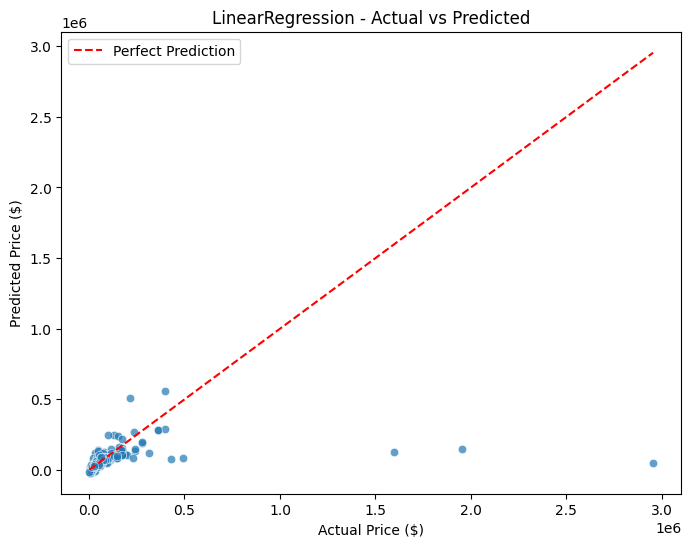


Ridge Test RMSE: 134,727.46, R^2: 0.1119


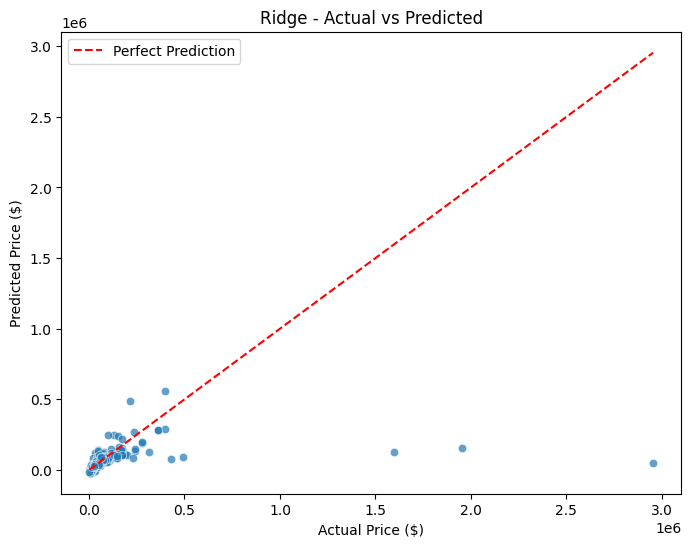


Lasso Test RMSE: 135,293.14, R^2: 0.1045


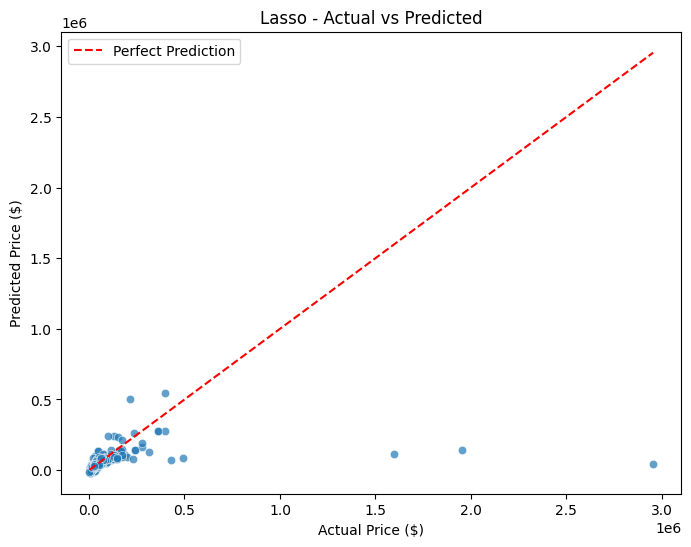


ElasticNet Test RMSE: 135,158.53, R^2: 0.1063


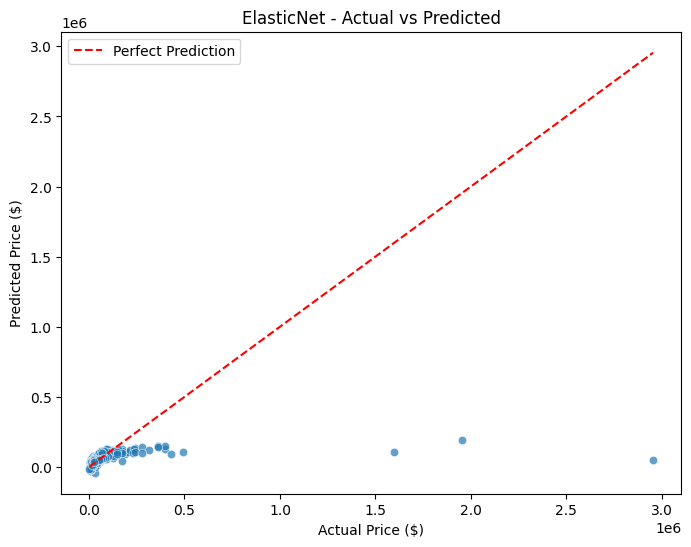

In [292]:
best_models_log = Linear_Regression(X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)

🥲 There’s not much improvement with **Lasso**, **Ridge**, or **ElasticNet** on the original data, comparing with baseline linear regression. 

Next up: will see if log-transforming the data gives these models any improvement.

---

## Log Transformed Data

In [298]:
plain_num_col = list(set(df_ml.columns) - set(cat_cols) - set(log_tf_cols) - set(log_cols))

df_ml_log = df_ml[plain_num_col + cat_cols + log_cols]

X_log = df_ml_log.drop('price_log', axis=1)
y_log = df_ml_log['price_log']

X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_log, y_log, test_size=0.2, random_state=42)



--- Tuning LinearRegression ---
Training Dimenstion: (3207, 14)
LinearRegression: No hyperparameters to tune

--- Tuning Ridge ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Ridge: {'model__alpha': 0.47129737561107793}
Best CV RMSE for Ridge: -0.3212460802750179

--- Tuning Lasso ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Lasso: {'model__alpha': 0.00014084824282460675}
Best CV RMSE for Lasso: -0.32372496154999875

--- Tuning ElasticNet ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for ElasticNet: {'model__alpha': 0.00017673501931861362, 'model__l1_ratio': 0.39279729768693794}
Best CV RMSE for ElasticNet: -0.32142540618452575

LinearRegression Test RMSE: 0.40, R^2: 0.7967


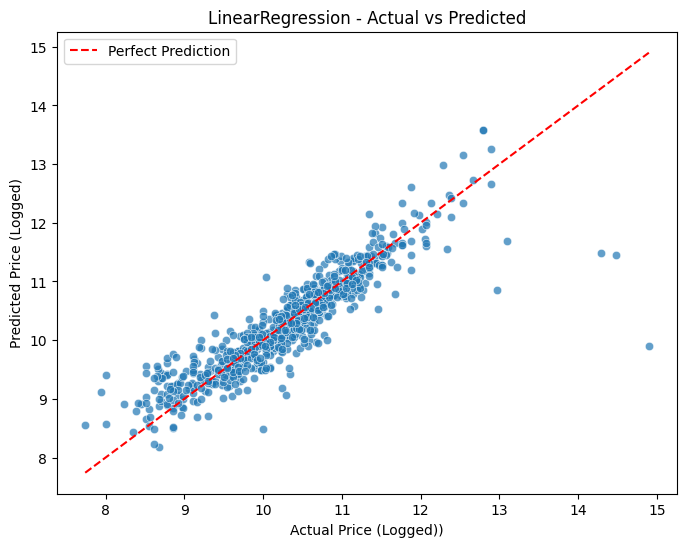


Ridge Test RMSE: 0.39, R^2: 0.8026


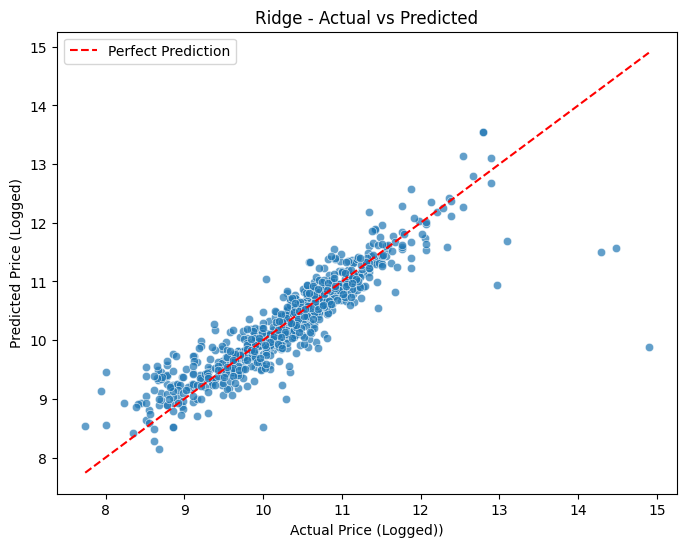


Lasso Test RMSE: 0.39, R^2: 0.8009


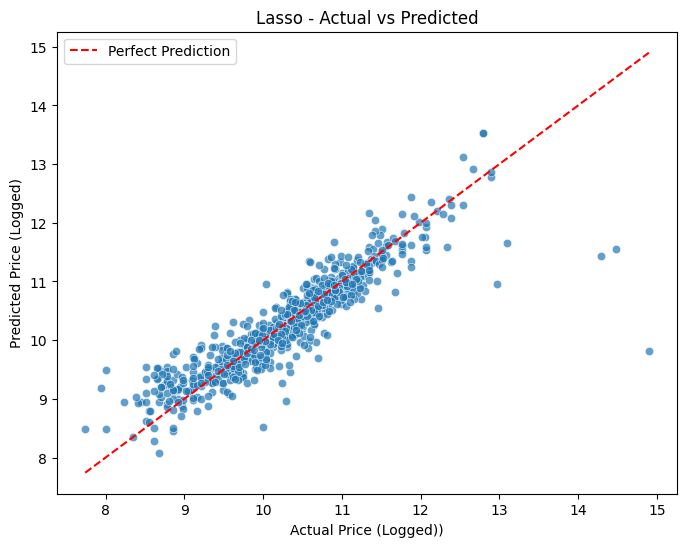


ElasticNet Test RMSE: 0.39, R^2: 0.8031


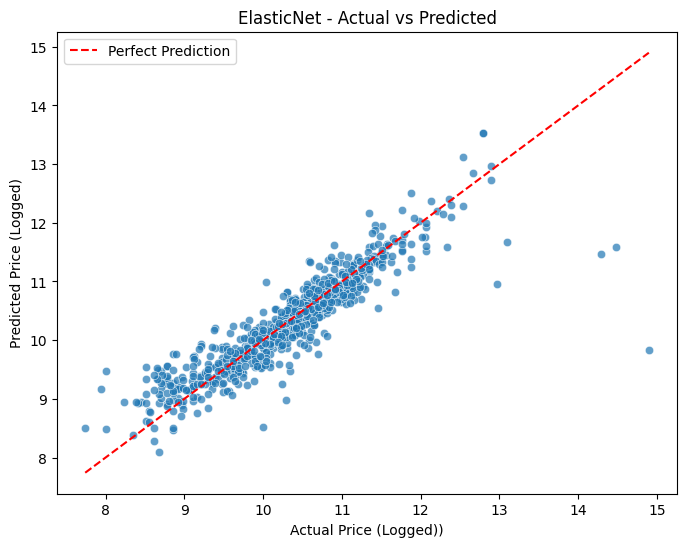

In [299]:
best_models_log = Linear_Regression(X_train=X_train_log, X_test=X_test_log, y_train=y_train_log, y_test=y_test_log, log_flag=True)

**Log target note.**  
Log-transforming `price`, `mileage`, and `hp` greatly improves fit by stabilizing variance and letting the model learn **percent** effects.  

However, it's challenging to interpret in actual dollar. Therefore, will see how the model perform by reversing the target - `price` to actual dollars.


--- Tuning LinearRegression ---
Training Dimenstion: (3207, 14)
LinearRegression: No hyperparameters to tune

--- Tuning Ridge ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Ridge: {'model__alpha': 0.47129737561107793}
Best CV RMSE for Ridge: -0.3212460802750179

--- Tuning Lasso ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Lasso: {'model__alpha': 0.00014084824282460675}
Best CV RMSE for Lasso: -0.32372496154999875

--- Tuning ElasticNet ---
Training Dimenstion: (3207, 14)
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for ElasticNet: {'model__alpha': 0.00017673501931861362, 'model__l1_ratio': 0.39279729768693794}
Best CV RMSE for ElasticNet: -0.32142540618452575

LinearRegression Test RMSE: 138,071.63, R^2: 0.0673


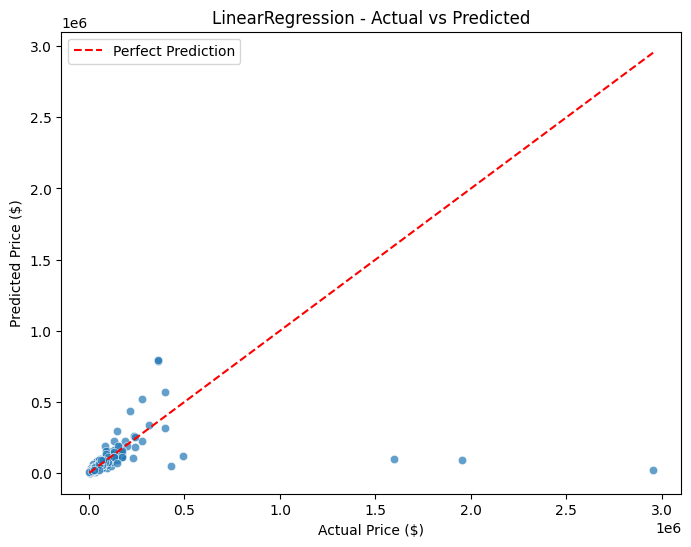


Ridge Test RMSE: 137,304.07, R^2: 0.0777


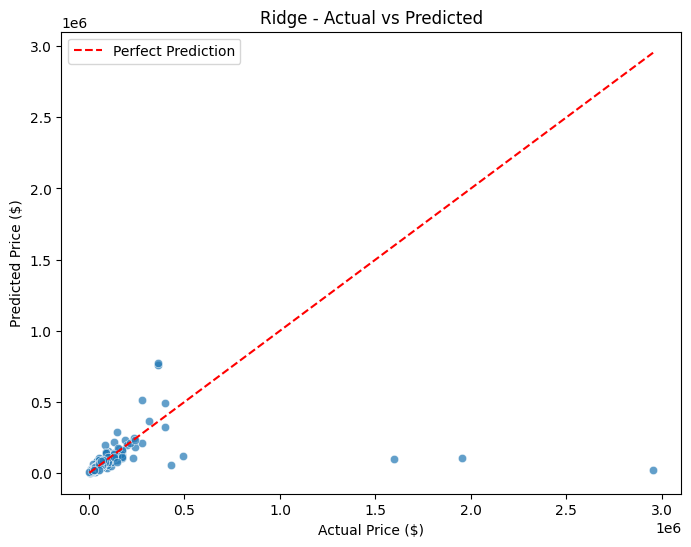


Lasso Test RMSE: 137,255.33, R^2: 0.0783


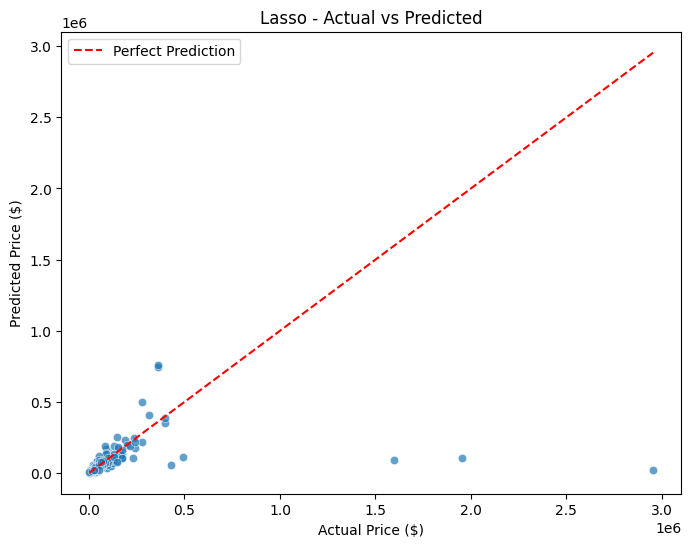


ElasticNet Test RMSE: 137,163.17, R^2: 0.0795


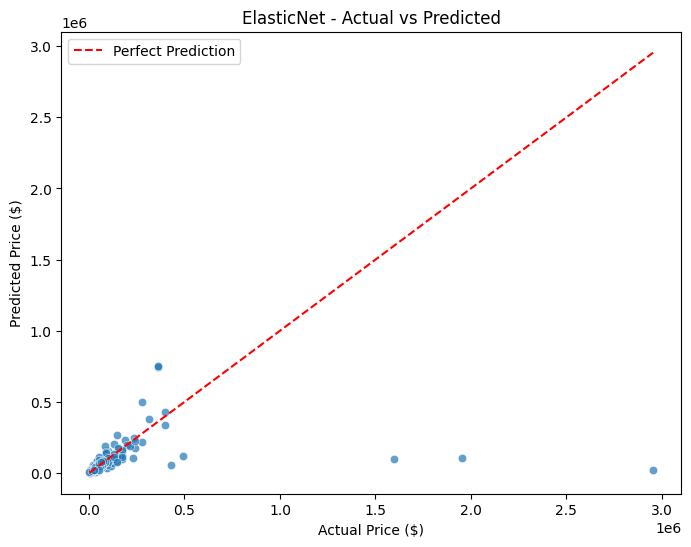

In [296]:
best_models_log_2 = Linear_Regression(X_train=X_train_log, X_test=X_test_log, y_train=y_train_log, y_test=y_test_log, reverse_log=True)

Surprisingly, after resersing, the model actual showed even worse performance than just using regular features.

⚠️ Cause:

The issue is r**etransformation bias**. When log-transform the target variable, train the model, and then use np.expm1() to convert back, this will introduce systematic bias.

❓ Why this happens:

- Model predicts the mean of log(price)
- But exp(mean(log(price))) ≠ mean(price)
- The exponential function is non-linear, so Jensen's inequality applies

😭 **The bias gets worse with:**

- Higher prediction variance
- More skewed data
- Larger prediction errors

**Next Step**:
- Will apply Bias correction (Duan's smearing estimator).

---

## Applied Bias Correction After Log Transformation of Price


--- Tuning LinearRegression ---
LinearRegression: No hyperparameters to tune
Bias correction factor for LinearRegression: 1.0339

--- Tuning Ridge ---
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Ridge: {'model__alpha': 0.47129737561107793}
Best CV RMSE for Ridge: 0.3212
Bias correction factor for Ridge: 1.0354

--- Tuning Lasso ---
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for Lasso: {'model__alpha': 0.00014084824282460675}
Best CV RMSE for Lasso: 0.3237
Bias correction factor for Lasso: 1.0399

--- Tuning ElasticNet ---
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best params for ElasticNet: {'model__alpha': 0.00017673501931861362, 'model__l1_ratio': 0.39279729768693794}
Best CV RMSE for ElasticNet: 0.3214
Bias correction factor for ElasticNet: 1.0378

TEST SET EVALUATION

LinearRegression Test Metrics:
  Uncorrected - RMSE: $138,071.63, MAE: $18,781.29, MAPE: 25.00%
  Corrected   - RMSE: $138,291.9

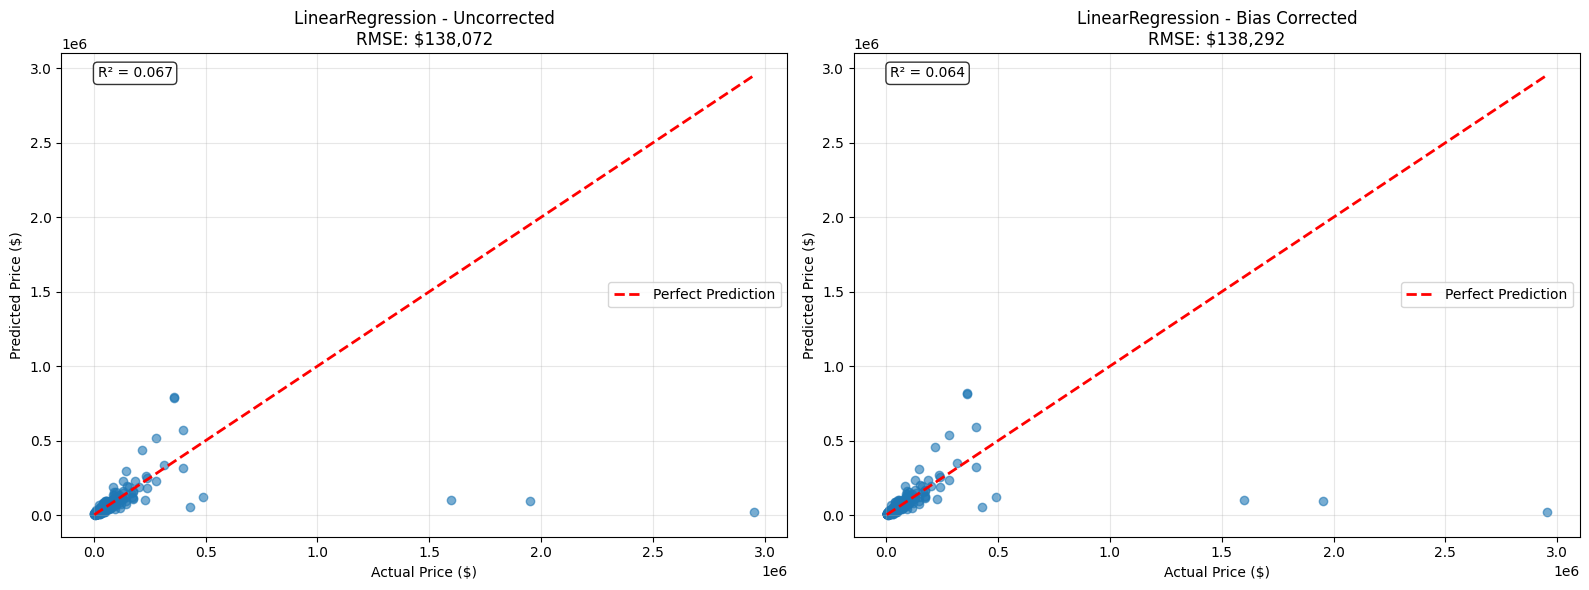


Ridge Test Metrics:
  Uncorrected - RMSE: $137,304.07, MAE: $18,159.99, MAPE: 24.46%
  Corrected   - RMSE: $137,450.59, MAE: $18,335.80, MAPE: 25.37%
  Improvement - RMSE: $-146.51 (-0.1%)


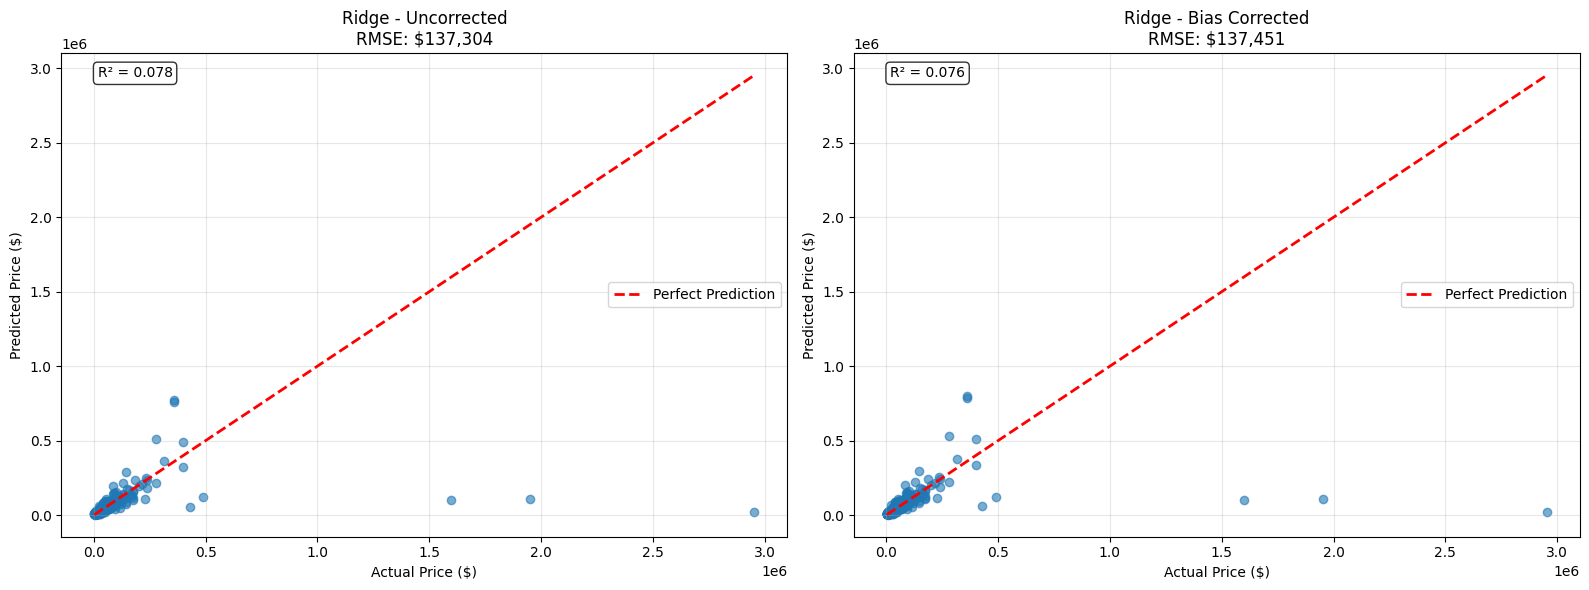


Lasso Test Metrics:
  Uncorrected - RMSE: $137,255.33, MAE: $18,022.80, MAPE: 24.29%
  Corrected   - RMSE: $137,387.99, MAE: $18,171.89, MAPE: 25.34%
  Improvement - RMSE: $-132.65 (-0.1%)


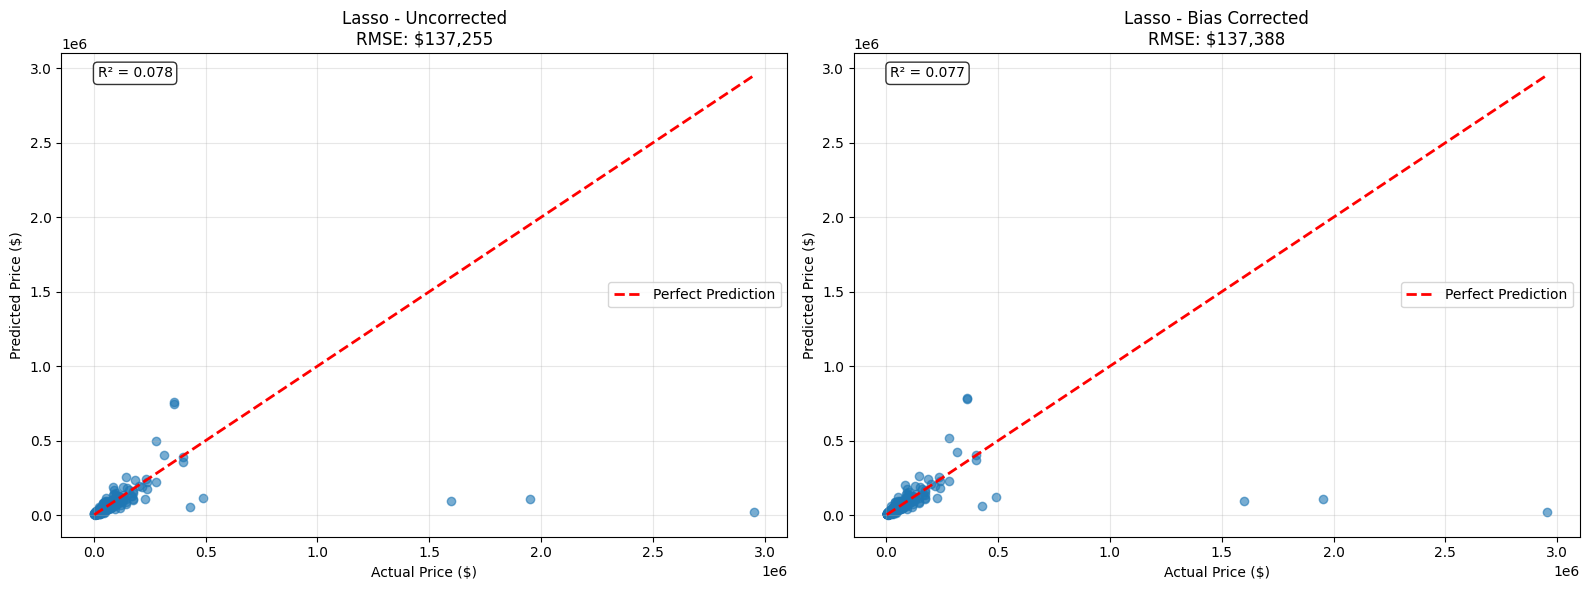


ElasticNet Test Metrics:
  Uncorrected - RMSE: $137,163.17, MAE: $18,002.13, MAPE: 24.21%
  Corrected   - RMSE: $137,289.97, MAE: $18,171.53, MAPE: 25.20%
  Improvement - RMSE: $-126.80 (-0.1%)


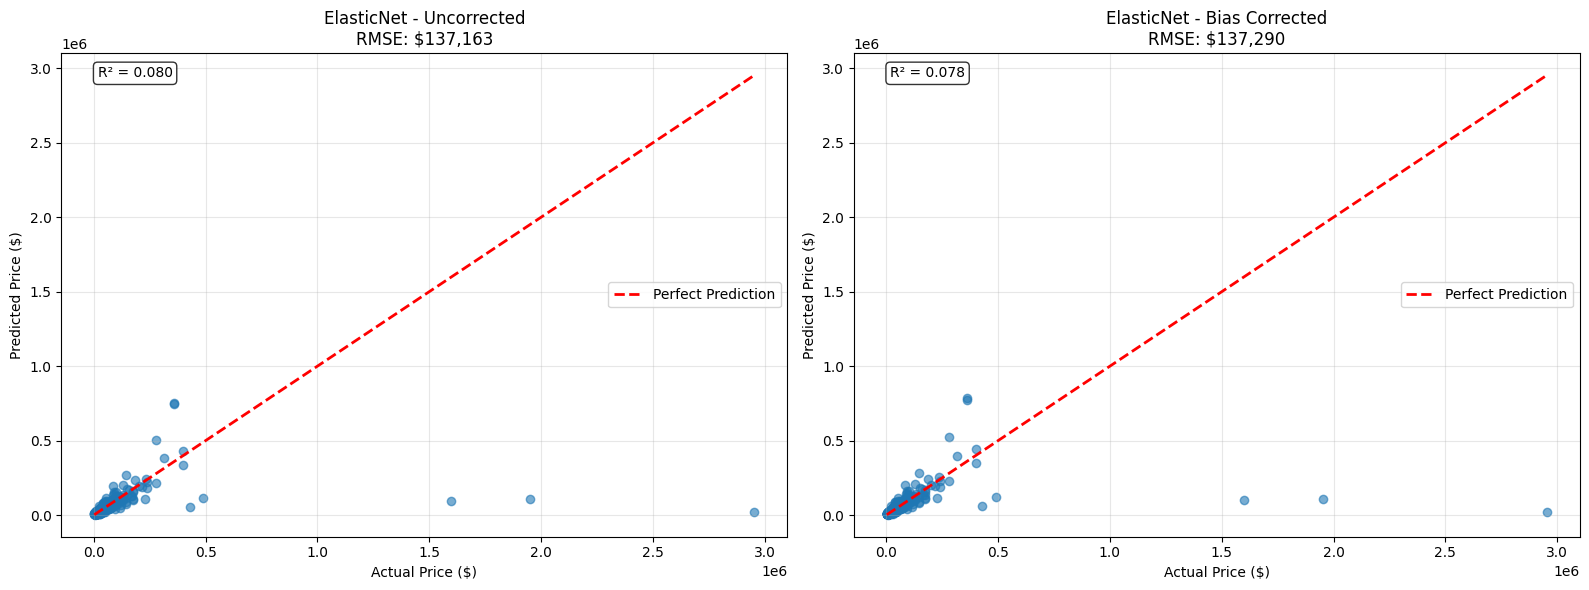

In [304]:
best_models, bias_corrections =  Linear_Regression_Log(X_train=X_train_log, X_test=X_test_log, y_train_log=y_train_log, y_test_log=y_test_log)

⚡ **Bias Correction After Log Transformation**

After training models on the log-transformed target and back-transforming predictions, I applied a standard bias correction to account for potential underestimation due to the nonlinearity of the exponential function. However, in this case, the bias-corrected and uncorrected predictions yielded almost identical RMSE and R² scores. 🤷‍♂️

**Interpretation:**  
This indicates the model’s log-scale residuals are pretty symmetric and have low variance, so the bias correction factor was near 1. For this dataset, bias correction doesn’t help—just use the log transformation and move on.

---

# 🔥 Summary

So far, baseline linear regression is absolute weak at prediction. Time to move on to models that might actually work better. 🚀

---